# DQN on Grid4x4 — Fixed demand vs demand bag (1200 s)

## Why this experiment

Usual RL training on Grid4x4 replays the **same traffic file every episode**. The agent can look like it is learning while mostly **memorizing one movie**. The usual in-training “test” is often on that same file, so it does not catch this.

Here we treat it like **train vs test**:
- **Train** = demand the agent practices on
- **Test (held-out)** = unseen demand files, scored with **no learning**

| Arm | Training traffic | What it tests |
|-----|------------------|---------------|
| **Fixed** | Same `fixed_1200.rou.xml` every episode | Easy baseline (one movie) |
| **Bag** | Rotate `train_00…09.rou.xml` | Harder — must handle changing routes |

- Episode length: **1200 s** (do not compare ATT to old 3600 s runs).
- Test set: `hold_00…02`, every 10 episodes.
- Agent: **DQN**, seeds **42** and **43**, **100** episodes.

**Judge success on test (held-out) ATT**, not on train ATT alone.  
**Gap** = test − train. Positive gap ⇒ worse on unseen demand than on train.

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO = Path('..').resolve()
OUT = REPO / 'data' / 'output_data' / 'tsc'
COLS = ['model', 'split', 'episode', 'travel_time', 'loss', 'reward', 'queue', 'delay', 'throughput']

RUNS = {
    ('fixed', 42): OUT / 'sumo_dqn_fixed1200' / 'sumo4x4' / 'dqn_fixed1200_s42' / 'logger',
    ('fixed', 43): OUT / 'sumo_dqn_fixed1200' / 'sumo4x4' / 'dqn_fixed1200_s43' / 'logger',
    ('bag', 42): OUT / 'sumo_dqn_bag1200' / 'sumo4x4' / 'dqn_bag1200_s42' / 'logger',
    ('bag', 43): OUT / 'sumo_dqn_bag1200' / 'sumo4x4' / 'dqn_bag1200_s43' / 'logger',
}


def load_dtl(logger_dir: Path) -> pd.DataFrame:
    paths = sorted(logger_dir.glob('*_DTL.log'))
    if not paths:
        raise FileNotFoundError(logger_dir)
    return pd.read_csv(paths[-1], sep='\t', header=None, names=COLS)


curves = []
for (condition, seed), logger_dir in RUNS.items():
    df = load_dtl(logger_dir)
    df = df.assign(condition=condition, seed=seed)
    curves.append(df)
    print(f"{condition:5s} seed={seed}  rows={len(df)}  log={logger_dir.name}")

all_df = pd.concat(curves, ignore_index=True)
train = all_df[all_df.split == 'TRAIN'].copy()
heldout = all_df[all_df.split == 'HELDOUT_MEAN'].copy()  # test curve
print('train points:', len(train), '| test (held-out) points:', len(heldout))

fixed seed=42  rows=144  log=logger
fixed seed=43  rows=144  log=logger
bag   seed=42  rows=144  log=logger
bag   seed=43  rows=144  log=logger
train points: 400 | test (held-out) points: 44


## 1. Test vs train (main generalization plot)

Each panel overlays **train** and **test** for one condition.

**What to look for:** do the lines stay close (generalizes), or does train pull ahead while test stays worse (memorizes)?

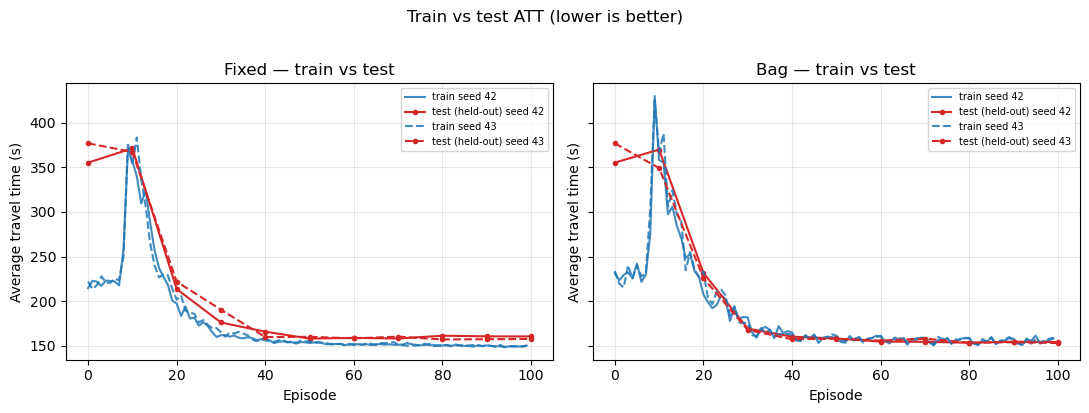

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, condition, title in [
    (axes[0], 'fixed', 'Fixed — train vs test'),
    (axes[1], 'bag', 'Bag — train vs test'),
]:
    for seed, ls in [(42, '-'), (43, '--')]:
        tr = train[(train.condition == condition) & (train.seed == seed)]
        te = heldout[(heldout.condition == condition) & (heldout.seed == seed)]
        ax.plot(tr.episode, tr.travel_time, color='C0', ls=ls, alpha=0.85,
                label=f'train seed {seed}')
        ax.plot(te.episode, te.travel_time, color='C3', ls=ls, marker='o', ms=3,
                label=f'test (held-out) seed {seed}')
    ax.set_title(title)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Average travel time (s)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='upper right')

fig.suptitle('Train vs test ATT (lower is better)', y=1.02)
fig.tight_layout()
plt.show()

### Reading this figure

- **Fixed (left):** train ATT drops lower than test. Late in training, train looks best but test stays higher → the agent is better on the movie it practiced than on unseen demand.
- **Bag (right):** train and test stay closer; test often ends **as good as or better than** train → varied training pushes the policy to transfer.
- Both seeds tell the same story (solid vs dashed), so it is not one lucky run.

## 2. Compare arms: all train curves vs all test curves

Left = practice score. Right = the score that matters for generalization.

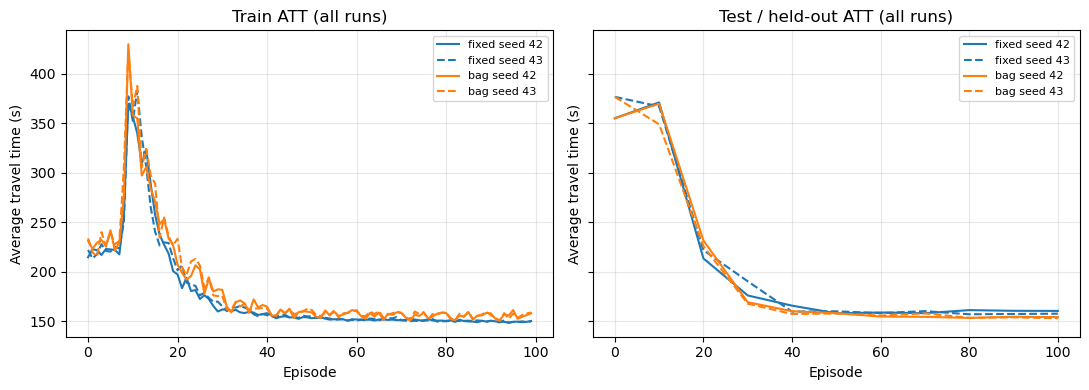

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
style = {
    ('fixed', 42): dict(color='C0', ls='-', label='fixed seed 42'),
    ('fixed', 43): dict(color='C0', ls='--', label='fixed seed 43'),
    ('bag', 42): dict(color='C1', ls='-', label='bag seed 42'),
    ('bag', 43): dict(color='C1', ls='--', label='bag seed 43'),
}
for key, kw in style.items():
    cond, seed = key
    tr = train[(train.condition == cond) & (train.seed == seed)]
    te = heldout[(heldout.condition == cond) & (heldout.seed == seed)]
    axes[0].plot(tr.episode, tr.travel_time, **kw)
    axes[1].plot(te.episode, te.travel_time, **kw)

axes[0].set_title('Train ATT (all runs)')
axes[1].set_title('Test / held-out ATT (all runs)')
for ax in axes:
    ax.set_xlabel('Episode')
    ax.set_ylabel('Average travel time (s)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### Reading this figure

- **Train (left):** fixed (blue) ends lower than bag (orange) → fixed *looks* better if you only watch training.
- **Test (right):** bag ends lower than fixed → bag wins on unseen demand.
- Takeaway: ranking by train ATT would pick the wrong winner for a generalization claim.

## 3. Generalization gap over training

Gap = **test ATT − train ATT** at each held-out checkpoint.  
Above zero = worse on test than on train.

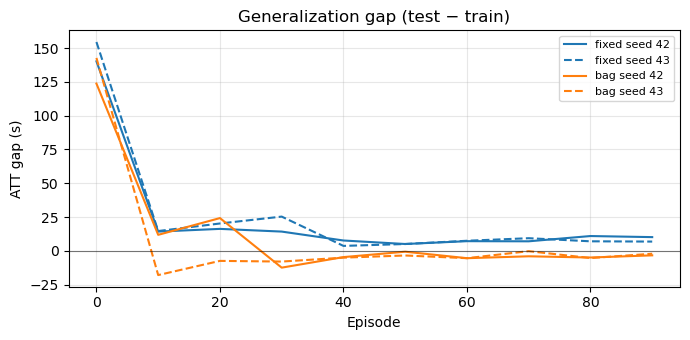

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.5))
for condition, color in [('fixed', 'C0'), ('bag', 'C1')]:
    for seed, ls in [(42, '-'), (43, '--')]:
        tr = train[(train.condition == condition) & (train.seed == seed)].set_index('episode')
        te = heldout[(heldout.condition == condition) & (heldout.seed == seed)].copy()
        te = te.assign(train_att=te.episode.map(tr['travel_time'])).dropna(subset=['train_att'])
        gap = te.travel_time - te.train_att
        ax.plot(te.episode, gap, color=color, ls=ls, label=f'{condition} seed {seed}')

ax.axhline(0, color='black', lw=0.8, alpha=0.5)
ax.set_title('Generalization gap (test − train)')
ax.set_xlabel('Episode')
ax.set_ylabel('ATT gap (s)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### Reading this figure

- **Fixed** stays clearly **above zero** by the end (~+8 to +10 s): test worse than train.
- **Bag** ends **at or below zero**: test matches or beats train.
- This gap plot is the cleanest single picture of memorization vs transfer.

## 4. Results table

In [14]:
rows = []
for (condition, seed), logger_dir in RUNS.items():
    df = load_dtl(logger_dir)
    tr = df[df.split == 'TRAIN'].iloc[-1]
    te = df[df.split == 'HELDOUT_MEAN'].iloc[-1]
    train_att = float(tr.travel_time)
    test_att = float(te.travel_time)
    rows.append({
        'condition': condition,
        'seed': seed,
        'episodes': int(tr.episode) + 1,
        'final_train_ATT': round(train_att, 1),
        'final_test_ATT': round(test_att, 1),
        'gap (test−train)': round(test_att - train_att, 1),
    })

results = pd.DataFrame(rows).sort_values(['condition', 'seed']).reset_index(drop=True)
display(results)

summary = (
    results.groupby('condition', as_index=False)
    .agg(
        mean_train_ATT=('final_train_ATT', 'mean'),
        mean_test_ATT=('final_test_ATT', 'mean'),
        mean_gap=('gap (test−train)', 'mean'),
    )
    .round(1)
)
print('Mean over seeds:')
display(summary)

,condition,seed,episodes,final_train_ATT,final_test_ATT,gap (test−train)
0,bag,42,100,158.2,154.4,-3.8
1,bag,43,100,159.0,153.2,-5.8
2,fixed,42,100,150.4,160.6,10.2
3,fixed,43,100,150.1,157.8,7.7


Mean over seeds:


,condition,mean_train_ATT,mean_test_ATT,mean_gap
0,bag,158.6,153.8,-4.8
1,fixed,150.2,159.2,9.0


## 5. Interpretation of the numbers

| Condition | Mean train | Mean test | Mean gap | Plain reading |
|-----------|------------|-----------|----------|---------------|
| **Fixed** | ~150 s | ~159 s | **+9 s** | Best-looking train score, but ~9 s worse on unseen demand |
| **Bag** | ~159 s | ~154 s | **−5 s** | Looks worse on train, **wins on test**, gap near/below zero |

**What this means**

1. **Fixed memorizes more.** Strong train, weaker test, positive gap — classic one-movie fit.
2. **Bag generalizes better.** Higher train ATT, but lower test ATT than fixed (~154 vs ~159).
3. **Do not trust train-only curves** for this benchmark question; they would wrongly crown fixed.
4. Both seeds agree, so the pattern is stable for this pilot.

**For the realism / benchmarking paper:** the usual fixed-demand protocol can overstate learning. Demand variety + held-out (test) eval is a fairer check of whether the agent learned something transferable.

More background: `extras/DEMAND_BAG_EXPERIMENT.md`.